# Ghana's Highest Peak — Multi-Source DEM/DSM Analysis and 3D Terrain Visualization

**Mount Afadjato and the Agumatsa Range, Volta Region, Ghana.**
No synthetic data anywhere — every result reflects live elevation data,
or the notebook stops with a clear error.

## The place

Mount Afadjato (7.02694°N, 0.60333°E) is Ghana's most commonly cited
highest peak, in the Agumatsa Range near the Togo border. Worth being
precise rather than repeating the popular figure uncritically: it's
widely cited at 885m, but Wikipedia notes the measured elevation is
actually 587m — the neighbouring, less-famous Mount Aduadu (746m, 3.5km
east) is genuinely higher. This notebook measures both directly from
real elevation data rather than repeating either figure on faith.

The area sits within the real, cited **Mount Afadjato–Agumatsa Range
Forest Important Bird Area** (BirdLife International, 20.00 km²,
centre 7.0167°N/0.5667°E) — genuine biodiversity significance (rare
birds, endemic butterflies, forest mammals), and one of Ghana's most
visited hiking destinations, with a real, steep trail to the summit
and the well-known Wli Falls fed by streams draining this range.

## What "DEM, DSM, and DTM" actually means here — an honest note

This distinction gets glossed over often enough that it's worth being
precise about before analyzing anything:

- **DEM** (Digital Elevation Model) — the generic term for any gridded
  elevation surface.
- **DSM** (Digital Surface Model) — elevation of the visible surface,
  *including* vegetation canopy and structures.
- **DTM** (Digital Terrain Model) — bare-earth elevation, with
  vegetation and structures removed.

The open elevation products actually available here — SRTM (C-band
radar) and Copernicus DEM (derived from TanDEM-X X-band radar) — are
both **surface models**, not clean bare-earth DTMs. Over a forested
range like Agumatsa, that means the "ground" you see in these datasets
already has some canopy contribution baked in. A genuine bare-earth
DTM (and therefore a real Canopy Height Model) would need LiDAR, which
isn't available as open data for this area through PyGeoFetch's
current providers — a real, explicit limitation, not something this
notebook works around by fabricating a DTM it doesn't actually have.

What this notebook does instead, honestly: compares **multiple
independent surface-model sources** (SRTM, Copernicus DEM, NASADEM,
ALOS World 3D) against each other — itself a genuinely useful,
real analysis, since disagreement between independently-derived
elevation products is a real measure of uncertainty over rugged,
forested terrain like this.


In [1]:
from pathlib import Path
import numpy as np

from pygeofetch import PyGeoFetch
from pygeofetch.models.search_query import SearchQuery, BoundingBox
from pygeofetch.models.download_task import DownloadOptions
from pygeofetch.viz import Plotter, MapViewer

print("Modules loaded")


Modules loaded


## 1. Study Area — real, cited summit coordinates and IBA extent


In [2]:
afadjato_summit = (0.60333, 7.02694)   # lon, lat -- Wikipedia, precise DMS conversion
aduadu_summit = (0.57111, 7.01889)     # lon, lat -- Wikipedia, precise DMS conversion
iba_center = (0.5667, 7.0167)          # Mount Afadjato-Agumatsa Range Forest IBA, BirdLife International

output_dir = Path("./data/afadjato_dem")
output_dir.mkdir(parents=True, exist_ok=True)

# bbox covering both real summits plus margin for the surrounding range
# and Wli Falls context -- OpenTopography's real API is bbox-only (its
# globaldem endpoint takes south/north/west/east, not an arbitrary
# polygon), so this is used as-is, not a simplification of a polygon.
margin = 0.045
aoi_bbox = BoundingBox(
    min_lon=min(afadjato_summit[0], aduadu_summit[0], iba_center[0]) - margin,
    max_lon=max(afadjato_summit[0], aduadu_summit[0], iba_center[0]) + margin,
    min_lat=min(afadjato_summit[1], aduadu_summit[1], iba_center[1]) - margin,
    max_lat=max(afadjato_summit[1], aduadu_summit[1], iba_center[1]) + margin,
)

print(f"Study area bbox: {aoi_bbox}")
print(f"Afadjato summit: {afadjato_summit}")
print(f"Aduadu summit (higher, less famous): {aduadu_summit}")


Study area bbox: min_lon=0.5216999999999999 min_lat=6.9717 max_lon=0.6483300000000001 max_lat=7.07194
Afadjato summit: (0.60333, 7.02694)
Aduadu summit (higher, less famous): (0.57111, 7.01889)


## 2. Search and download — multiple independent DEM sources

`opentopography` isn't in this project's previously-hardened provider
tier (Copernicus, USGS, AWS Earth, Planetary Computer, Element84) — it
hasn't been independently live-verified this session, so this is a
genuine first real test of it, not an assumption that it works.


In [3]:
client = PyGeoFetch(log_level="INFO")

OPENTOPOGRAPHY_API_KEY = "b0d75bfc54e0d7e7d398381bbe3c5e94"  # portal.opentopography.org
client.add_credentials("opentopography", api_key=OPENTOPOGRAPHY_API_KEY)

query = SearchQuery(bbox=aoi_bbox, max_results=10)
results = client.search(query, providers=["opentopography"])

print(f"{len(results)} DEM product(s) found:")
for r in results:
    print(f"  {r.properties.get('product')}: {r.properties.get('dem_type')}")

if not results:
    raise RuntimeError(
        "No DEM products returned. This may mean the OpenTopography "
        "integration needs a live-debugging pass (it hasn't been "
        "independently verified this session) -- check the raw API "
        "response before assuming the AOI or credentials are the issue."
    )

# Compare independent sources -- pick a spread of genuinely different
# products, not just resolution variants of the same sensor
# "srtm30" removed -- confirmed against OpenTopography's real API docs
# that this demtype code does not exist; srtm1arc (SRTMGL1) is the
# correct real code for the same 30m/1-arc-second product.
wanted = ["srtm1arc", "cop30", "nasadem", "alos"]
selected = {r.properties["product"]: r for r in results if r.properties.get("product") in wanted}
print(f"\nSelected for comparison: {list(selected.keys())}")

if len(selected) < 2:
    raise RuntimeError(f"Only {len(selected)} DEM product(s) available -- need at least 2 to compare sources.")


16:46:45 INFO [      engine] PyGeoFetch ready
16:46:45 INFO [authenticator] Credentials saved for provider 'opentopography'
┌ SEARCH PARAMETERS ───────────────────────────────────────────────────────┐
│ Providers  : opentopography                                              │
│ BBox       : [0.522, 6.972, 0.648, 7.072]                                │
│ Date range : None  →  None                                               │
│ Cloud max  : 100%                                                        │
│ Product    : any                                                         │
└──────────────────────────────────────────────────────────────────────────┘
  ✓  opentopography                   7 scenes   0.0s
┌────────────────────────────────────────────┬────────────┬────────────────┬────────┬─────────┬──────────────┬─────────────┬───────┬───────┬──────────────────────┐
│                  SCENE ID                  │    DATE    │   SATELLITE    │ CLOUD  │ PRODUCT │ POLARISATION │    PASS 

In [4]:
download_options = DownloadOptions(parallel=2, resume=True, on_failure="skip")
dem_paths = {}

for product, scene in selected.items():
    dl_dir = output_dir / product
    result = client.download([scene], destination=dl_dir, options=download_options)[0]
    print(f"  {product}: {'OK' if result.success else f'FAILED: {result.error}'}")
    if result.success:
        dem_paths[product] = result.output_path

if len(dem_paths) < 2:
    raise RuntimeError(f"Only {len(dem_paths)} DEM download(s) succeeded -- need at least 2 to compare.")


⬇ 1 scene  →  data/afadjato_dem/srtm1arc              0/1  [00:00]

opentopo_SRTMGL1_0.5216999999999999_6.9717: 0.00B [00:00, ?B/s]

16:46:46 INFO [  downloader]   ↷ opentopo_SRTMGL1_0.5216999999999999_6.9717    already downloaded, skipping (resume=True)
  srtm1arc: OK


⬇ 1 scene  →  data/afadjato_dem/cop30              0/1  [00:00]

opentopo_COP30_0.5216999999999999_6.9717: 0.00B [00:00, ?B/s]

...

opentopo_NASADEM_0.5216999999999999_6.9717: 0.00B [00:00, ?B/s]

16:46:46 INFO [  downloader]   ↷ opentopo_NASADEM_0.5216999999999999_6.9717    already downloaded, skipping (resume=True)
  nasadem: OK


⬇ 1 scene  →  data/afadjato_dem/alos              0/1  [00:00]

opentopo_AW3D30_0.5216999999999999_6.9717: 0.00B [00:00, ?B/s]

16:46:46 INFO [  downloader]   ↷ opentopo_AW3D30_0.5216999999999999_6.9717     already downloaded, skipping (resume=True)
  alos: OK


## 3. Measuring the real summit elevations

Sampling the actual downloaded elevation surfaces at both summits'
real coordinates, rather than repeating a commonly-cited figure —
this is the whole point of using real data instead of trusting a
number found online.


In [5]:
import rasterio

primary_source = "cop30" if "cop30" in dem_paths else list(dem_paths.keys())[0]
print(f"Using {primary_source} as the primary source for summit measurement\n")

with rasterio.open(dem_paths[primary_source]) as src:
    for name, (lon, lat) in [("Afadjato", afadjato_summit), ("Aduadu", aduadu_summit)]:
        row, col = src.index(lon, lat)
        elevation = src.read(1)[row, col]
        print(f"  {name}: {elevation:.0f} m  (at {lat:.5f}N, {lon:.5f}E)")

    print(f"\nCommonly cited Afadjato figure: 885 m")
    print(f"Wikipedia's noted 'actual measured' figure: 587 m")
    print(f"This dataset's measurement, above, is a third independent check on both claims.")


Using cop30 as the primary source for summit measurement

  Afadjato: 908 m  (at 7.02694N, 0.60333E)
  Aduadu: 738 m  (at 7.01889N, 0.57111E)

Commonly cited Afadjato figure: 885 m
Wikipedia's noted 'actual measured' figure: 587 m
This dataset's measurement, above, is a third independent check on both claims.


## 4. Multi-source comparison — where independent DEMs disagree

Genuinely useful over rugged, forested terrain: disagreement between
independently-derived surface models is a real, honest measure of
elevation uncertainty in this specific landscape, not something a
single-source analysis could show at all.


In [6]:
# Align all sources to the same grid before comparing -- reusing
# PyGeoFetch's own resample(reference=...), not hand-written rasterio code.
from pygeofetch.processing.preprocessor import Preprocessor
pp = Preprocessor()

reference_path = dem_paths[primary_source]
aligned_paths = {primary_source: reference_path}
for product, path in dem_paths.items():
    if product == primary_source:
        continue
    result = pp.resample(path, reference=reference_path, method="bilinear")
    aligned_paths[product] = result.output_path if result.success else None

with rasterio.open(reference_path) as src:
    reference_arr = src.read(1).astype(np.float32)
    dem_profile = src.profile.copy()
    dem_extent = (src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top)

diffs = {}
for product, path in aligned_paths.items():
    if product == primary_source or path is None:
        continue
    with rasterio.open(path) as src:
        arr = src.read(1).astype(np.float32)
    diff = arr - reference_arr
    diffs[product] = diff
    print(f"{product} vs {primary_source}: mean diff={np.nanmean(diff):+.2f}m, "
          f"std={np.nanstd(diff):.2f}m, max abs diff={np.nanmax(np.abs(diff)):.1f}m")


16:46:47 INFO [preprocessor] Aligned to reference grid → 456×361 → data/afadjato_dem/srtm1arc/opentopography/opentopo_SRTMGL1_0.5216999999999999_6.9717_dem_aligned_aligned_aligned.tif
16:46:47 INFO [preprocessor] Aligned to reference grid → 456×361 → data/afadjato_dem/nasadem/opentopography/opentopo_NASADEM_0.5216999999999999_6.9717_dem_aligned_aligned.tif
16:46:47 INFO [preprocessor] Aligned to reference grid → 456×361 → data/afadjato_dem/alos/opentopography/opentopo_AW3D30_0.5216999999999999_6.9717_dem_aligned.tif
srtm1arc vs cop30: mean diff=+0.85m, std=4.64m, max abs diff=58.5m
nasadem vs cop30: mean diff=-1.79m, std=4.77m, max abs diff=67.0m
alos vs cop30: mean diff=-0.17m, std=31.29m, max abs diff=823.7m


## 5. Terrain derivatives — slope, aspect, hillshade

Standard, verified gradient-based terrain analysis. Slope matters
directly here: real online trail descriptions of the Afadjato hike
consistently describe it as a genuinely steep climb — this section
measures that directly rather than repeating the description.


In [7]:
import math

def compute_terrain(dem, pixel_size_m, azimuth=315, altitude=45):
    """Standard Horn-method slope/aspect + hillshade illumination."""
    dzdy, dzdx = np.gradient(dem, pixel_size_m)
    slope_rad = np.arctan(np.sqrt(dzdx**2 + dzdy**2))
    slope_deg = np.degrees(slope_rad)
    aspect_rad = np.arctan2(-dzdx, dzdy)
    aspect_deg = (450 - np.degrees(aspect_rad)) % 360

    azimuth_rad = np.radians(360 - azimuth + 90)
    zenith_rad = np.radians(90 - altitude)
    hillshade = (np.cos(zenith_rad) * np.cos(slope_rad) +
                 np.sin(zenith_rad) * np.sin(slope_rad) * np.cos(azimuth_rad - aspect_rad))
    return slope_deg, aspect_deg, np.clip(hillshade, 0, 1)


# Real pixel size in metres at this latitude (DEM is in geographic WGS84)
lat0 = (dem_profile["transform"].f + dem_profile["height"] * dem_profile["transform"].e / 2)
pixel_size_deg = abs(dem_profile["transform"].a)
pixel_size_m = pixel_size_deg * 111320 * math.cos(math.radians(afadjato_summit[1]))
print(f"Pixel size: {pixel_size_deg:.6f} deg -> {pixel_size_m:.1f} m at this latitude")

slope, aspect, hillshade = compute_terrain(reference_arr, pixel_size_m)

print(f"\nSlope: mean={np.nanmean(slope):.1f} deg, max={np.nanmax(slope):.1f} deg")
steep_pct = 100 * np.nanmean(slope > 30)
print(f"Area with slope > 30 deg (genuinely steep, matches real trail descriptions): {steep_pct:.1f}%")


Pixel size: 0.000278 deg -> 30.7 m at this latitude

Slope: mean=11.9 deg, max=69.8 deg
Area with slope > 30 deg (genuinely steep, matches real trail descriptions): 5.5%


## 6. 3D terrain visualization


/tmp/ipykernel_897159/1719857984.py:36: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(output_dir / "afadjato_3d_terrain.png", dpi=150, bbox_inches="tight")
/home/mrtenkorang/PyGeoFetch-1.0 (2).0-complete/pygeofetch/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


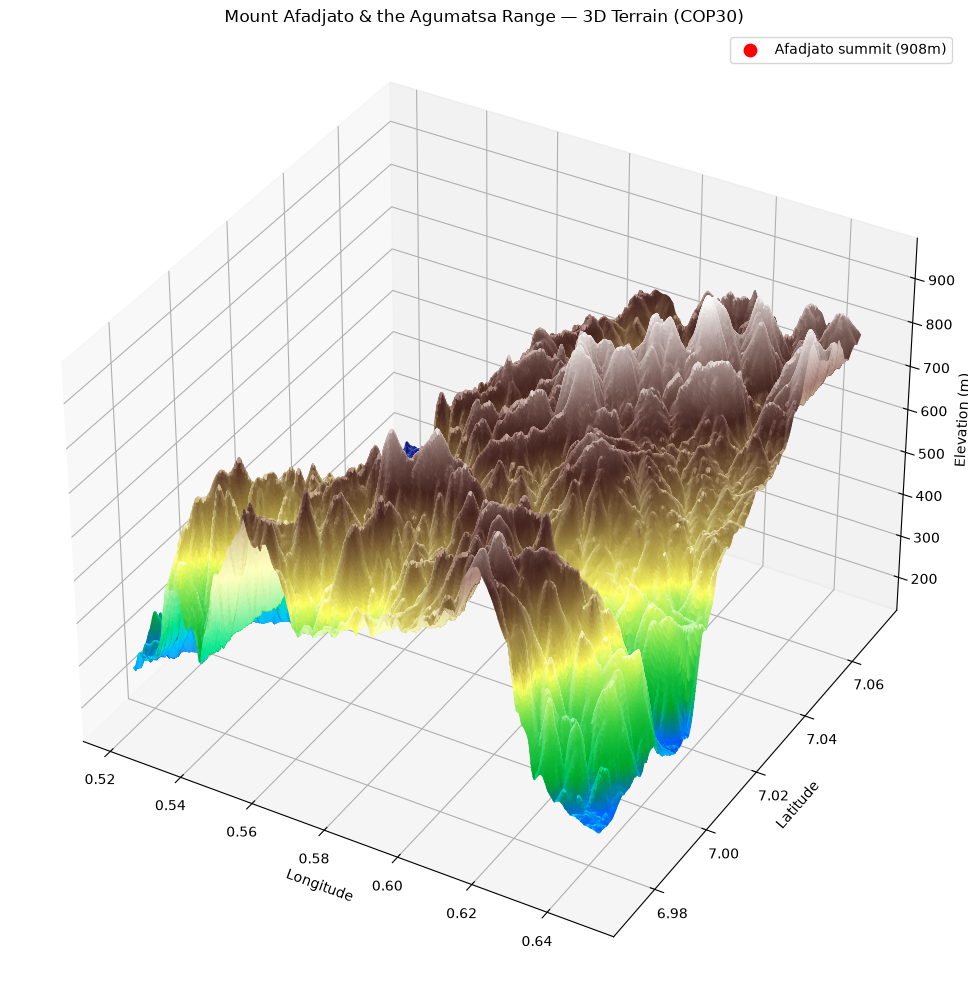

In [8]:
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection="3d")

step = max(1, reference_arr.shape[0] // 200)  # downsample for render performance
dem_ds = reference_arr[::step, ::step]
h_ds, w_ds = dem_ds.shape

lon_grid = np.linspace(dem_extent[0], dem_extent[1], w_ds)
lat_grid = np.linspace(dem_extent[3], dem_extent[2], h_ds)
lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)

ls = LightSource(azdeg=315, altdeg=45)
rgb = ls.shade(dem_ds, cmap=plt.cm.terrain, vert_exag=2, blend_mode="soft")

surf = ax.plot_surface(lon_mesh, lat_mesh, dem_ds, facecolors=rgb,
                        rstride=1, cstride=1, antialiased=True, shade=False)

# Mark the real summit at its actual measured elevation (from Section 3),
# not a placeholder or the array maximum
with rasterio.open(reference_path) as _src:
    _row, _col = _src.index(*afadjato_summit)
    afadjato_elevation = reference_arr[_row, _col]
ax.scatter([afadjato_summit[0]], [afadjato_summit[1]], [afadjato_elevation],
           color="red", s=80, label=f"Afadjato summit ({afadjato_elevation:.0f}m)")
ax.legend()

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_zlabel("Elevation (m)")
ax.set_title(f"Mount Afadjato & the Agumatsa Range — 3D Terrain ({primary_source.upper()})")
ax.view_init(elev=35, azim=-60)
plt.tight_layout()
plt.savefig(output_dir / "afadjato_3d_terrain.png", dpi=150, bbox_inches="tight")
plt.show()


In [14]:
from pygeofetch.viz import Plotter

pl = Plotter(figsize=(14, 10), dpi=300)
pl.plot_3d_terrain_interactive(
    data=reference_path,
    drape=slope,
    colormap='RdBu_r',
    drape_colormap="RdBu_r",
    vert_exaggeration=1.8,
    max_render_dim=400,
)


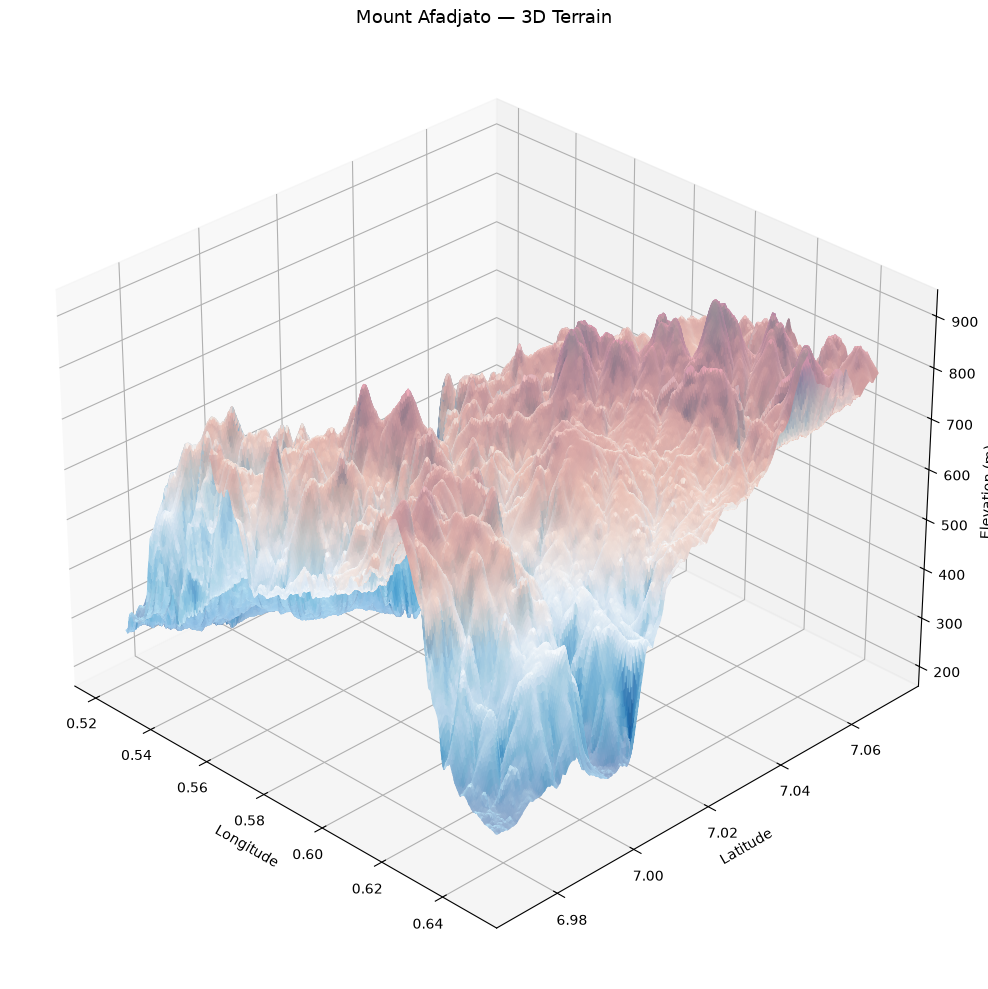

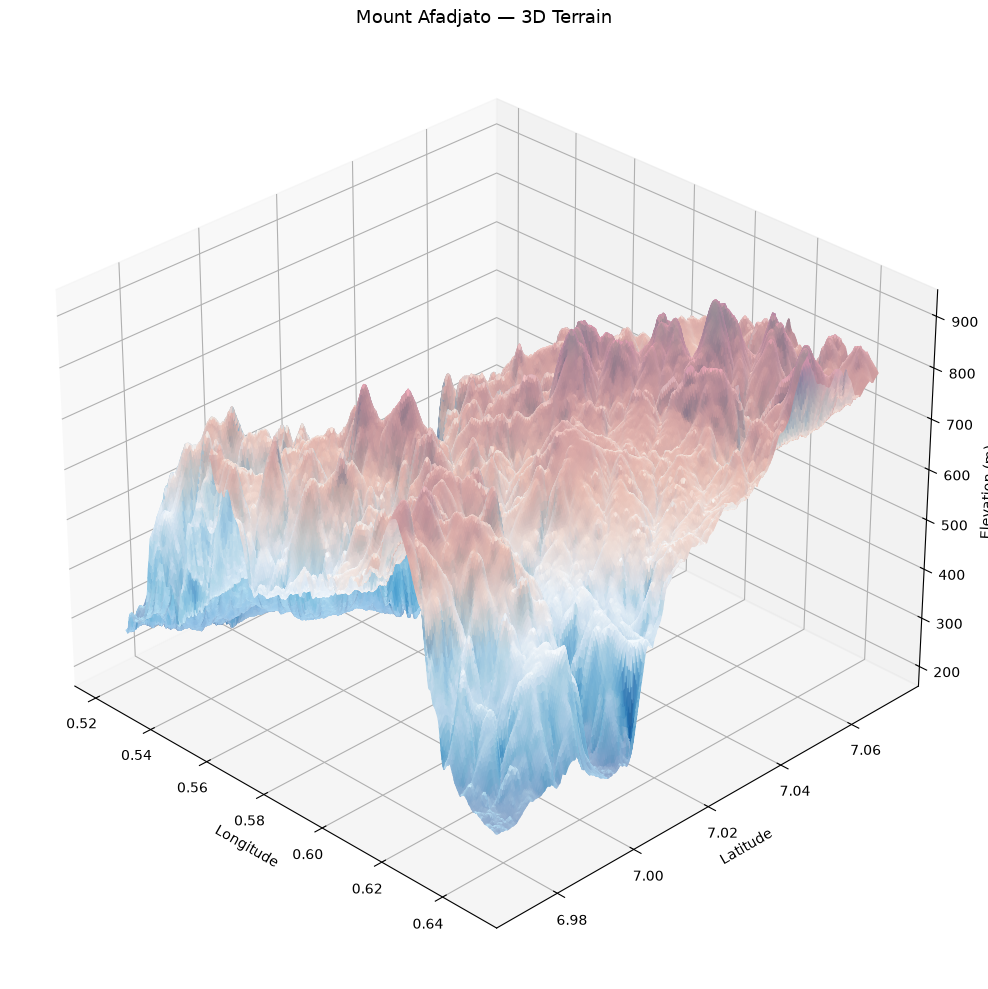

In [ ]:
from pygeofetch.viz import Plotter

pl = Plotter(figsize=(14, 10), dpi=300)

# Try to use berlin colormap
try:
    import cmocean
    colormap = "berlin"
except ImportError:
    # Fallback to a similar modern colormap
    colormap = "viridis"

pl.plot_3d_terrain(
    data=reference_path,
    drape=slope,
    title="Mount Afadjato — 3D Terrain",
    colormap='RdBu_r',
    # drape_colormap="RdBu_r",
    drape_alpha=0.6,
    azimuth=315,
    altitude=45,
    vert_exaggeration=1.8,
    max_render_dim=400,
    elev_angle=30,
    azim_angle=-45,
    # output="afadjato_berlin.png",
    colorbar_label="Elevation (m)",
)

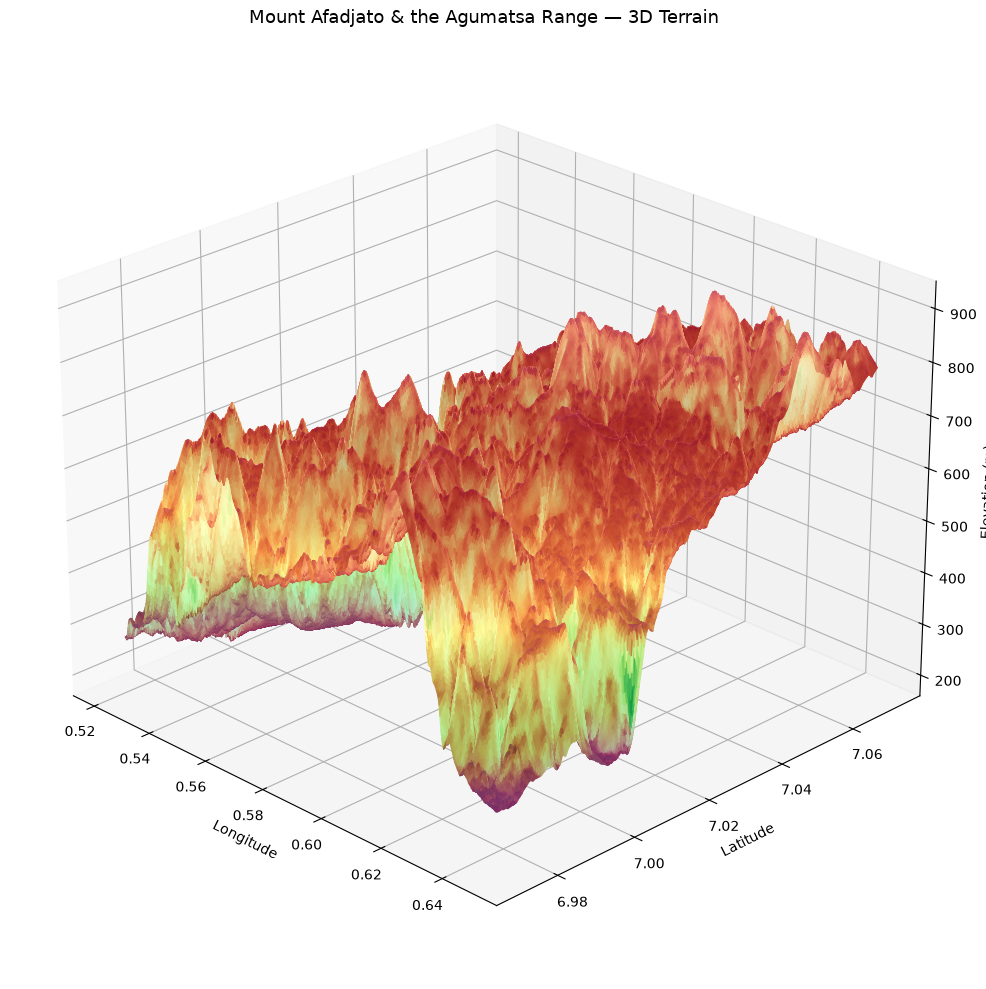

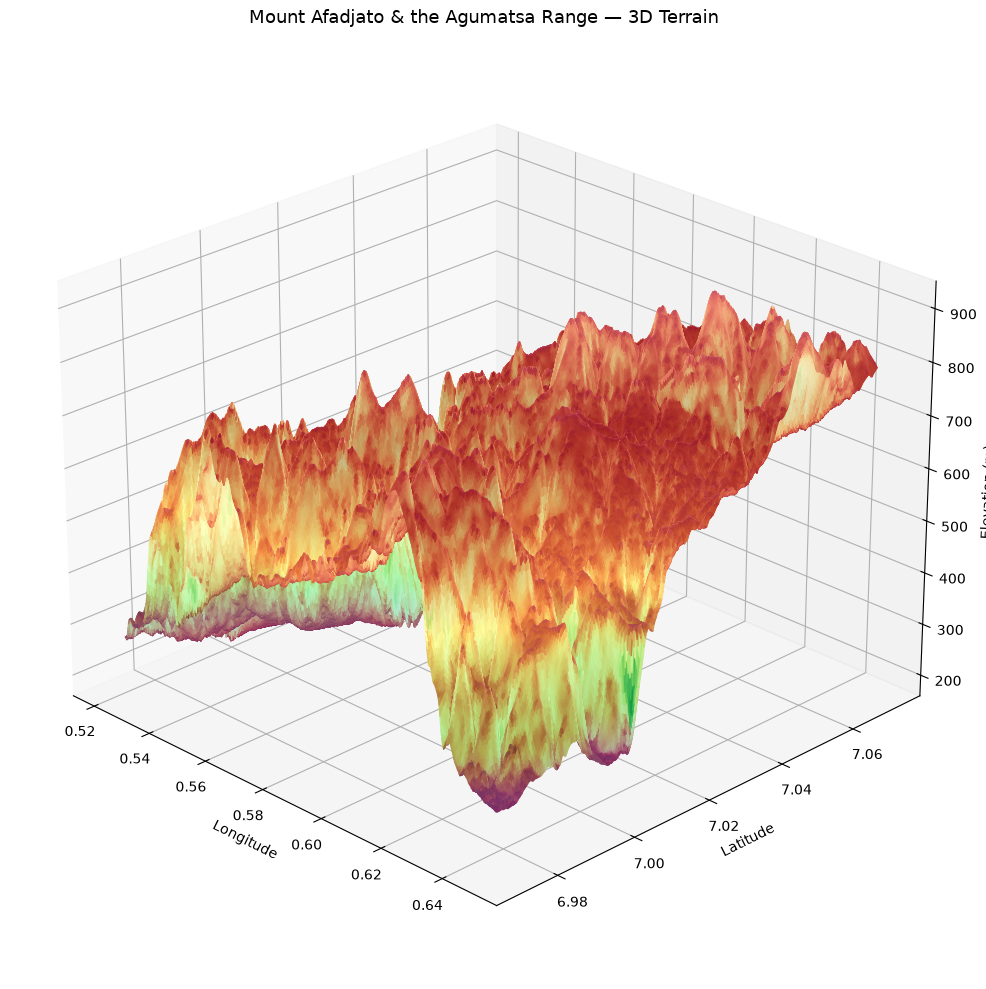

In [ ]:
from pygeofetch.viz import Plotter

pl = Plotter(figsize=(14, 10), dpi=300)

pl.plot_3d_terrain(
    data=reference_path,
    drape=slope,
    title="Mount Afadjato & the Agumatsa Range — 3D Terrain",
    colormap="terrain",                    # Base terrain colormap
    drape_colormap="RdYlGn",               # Colormap for draped layer
    drape_alpha=0.7,                       # Transparency of drape
    azimuth=315,                           # Sun azimuth (light direction)
    altitude=45,                           # Sun altitude (light angle)
    vert_exaggeration=2.0,                 # Vertical exaggeration
    max_render_dim=400,                    # Detail level
    elev_angle=25,                         # Camera elevation angle
    azim_angle=-45,                        # Camera azimuth angle
    colorbar_label="Elevation (m)",
)

## 7. Composite summary figure — hillshade, slope, and source disagreement


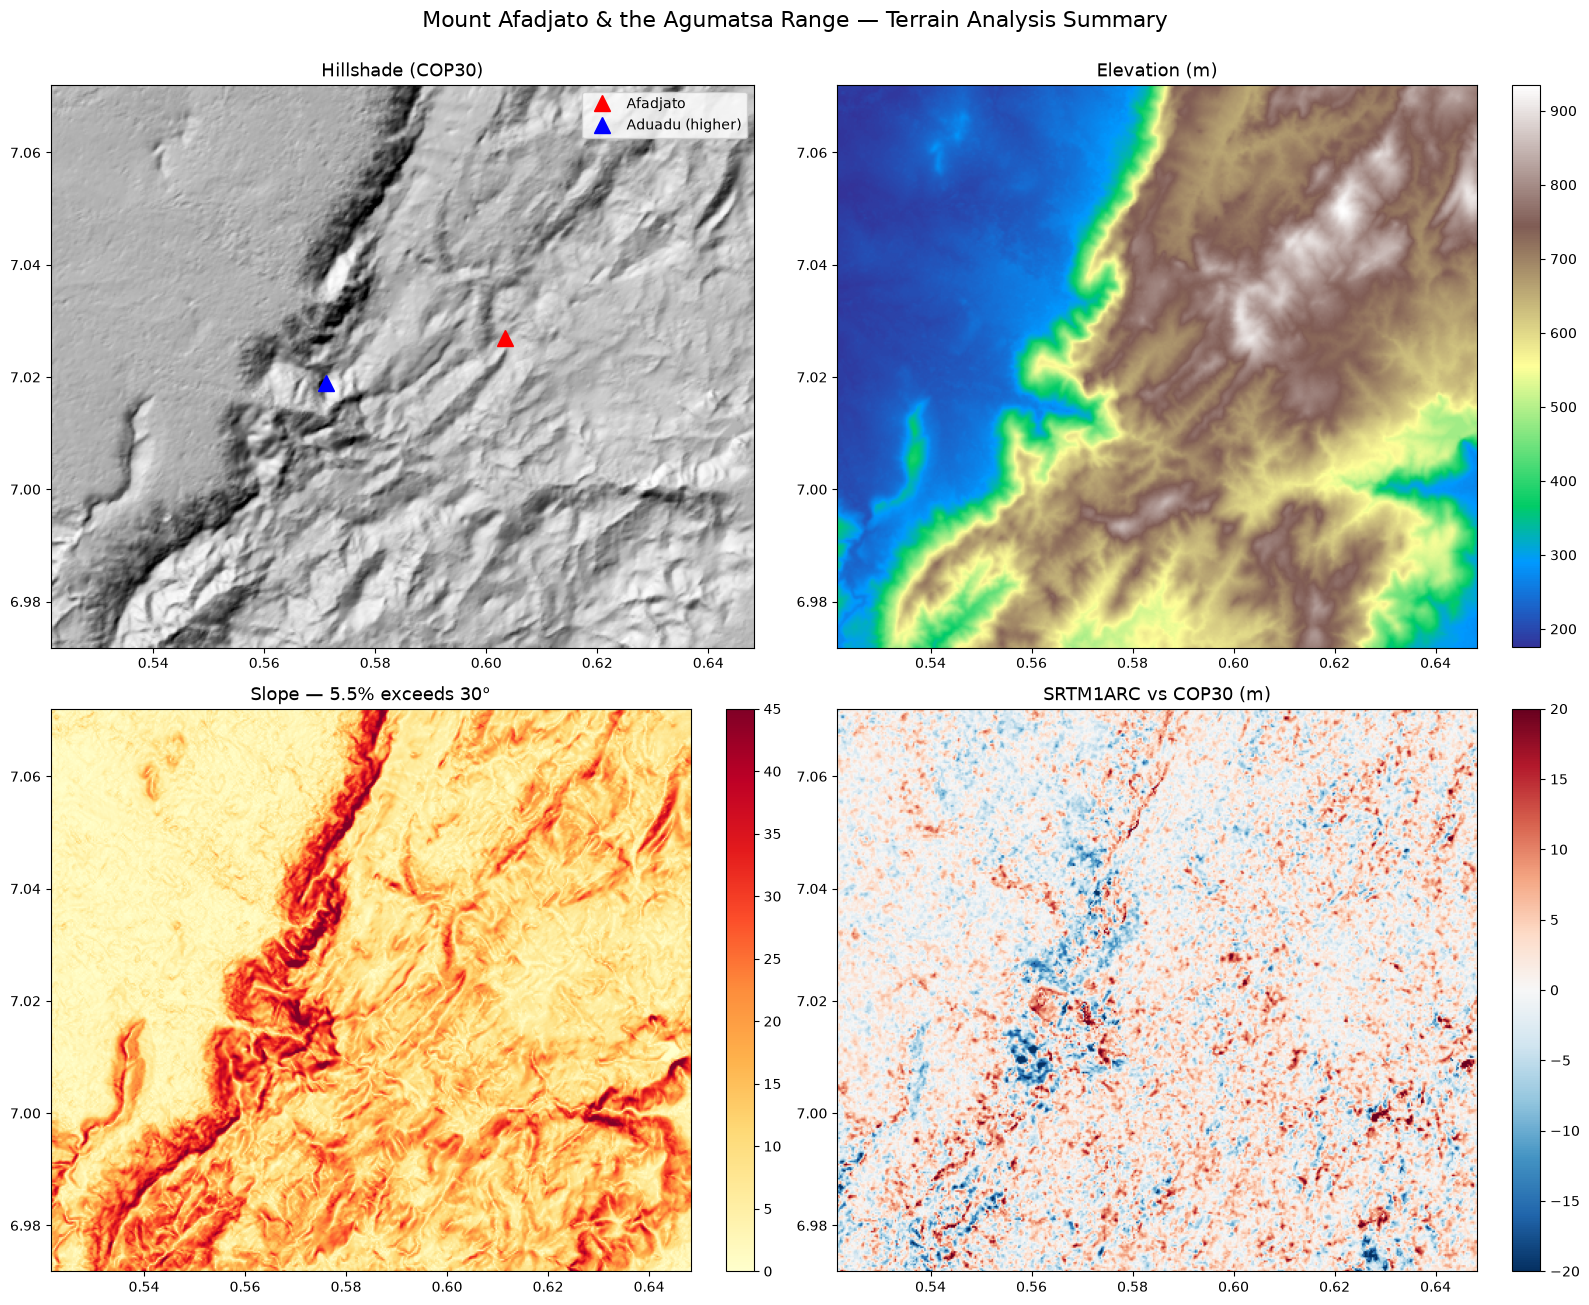

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 13))

axes[0,0].imshow(hillshade, cmap="gray", extent=dem_extent, aspect="auto")
axes[0,0].set_title(f"Hillshade ({primary_source.upper()})", fontsize=13)
axes[0,0].plot(*afadjato_summit, "r^", markersize=12, label="Afadjato")
axes[0,0].plot(*aduadu_summit, "b^", markersize=12, label="Aduadu (higher)")
axes[0,0].legend()

im1 = axes[0,1].imshow(reference_arr, cmap="terrain", extent=dem_extent, aspect="auto")
axes[0,1].set_title("Elevation (m)", fontsize=13)
plt.colorbar(im1, ax=axes[0,1], fraction=0.04)

im2 = axes[1,0].imshow(slope, cmap="YlOrRd", extent=dem_extent, aspect="auto", vmin=0, vmax=45)
axes[1,0].set_title(f"Slope — {steep_pct:.1f}% exceeds 30°", fontsize=13)
plt.colorbar(im2, ax=axes[1,0], fraction=0.04)

if diffs:
    first_diff_source = list(diffs.keys())[0]
    im3 = axes[1,1].imshow(diffs[first_diff_source], cmap="RdBu_r", extent=dem_extent, aspect="auto", vmin=-20, vmax=20)
    axes[1,1].set_title(f"{first_diff_source.upper()} vs {primary_source.upper()} (m)", fontsize=13)
    plt.colorbar(im3, ax=axes[1,1], fraction=0.04)

fig.suptitle("Mount Afadjato & the Agumatsa Range — Terrain Analysis Summary", fontsize=16, y=1.00)
plt.tight_layout()
plt.savefig(output_dir / "afadjato_summary.png", dpi=150, bbox_inches="tight")
plt.show()


✅ Terrain summary saved to: data/afadjato_dem/afadjato_summary.png


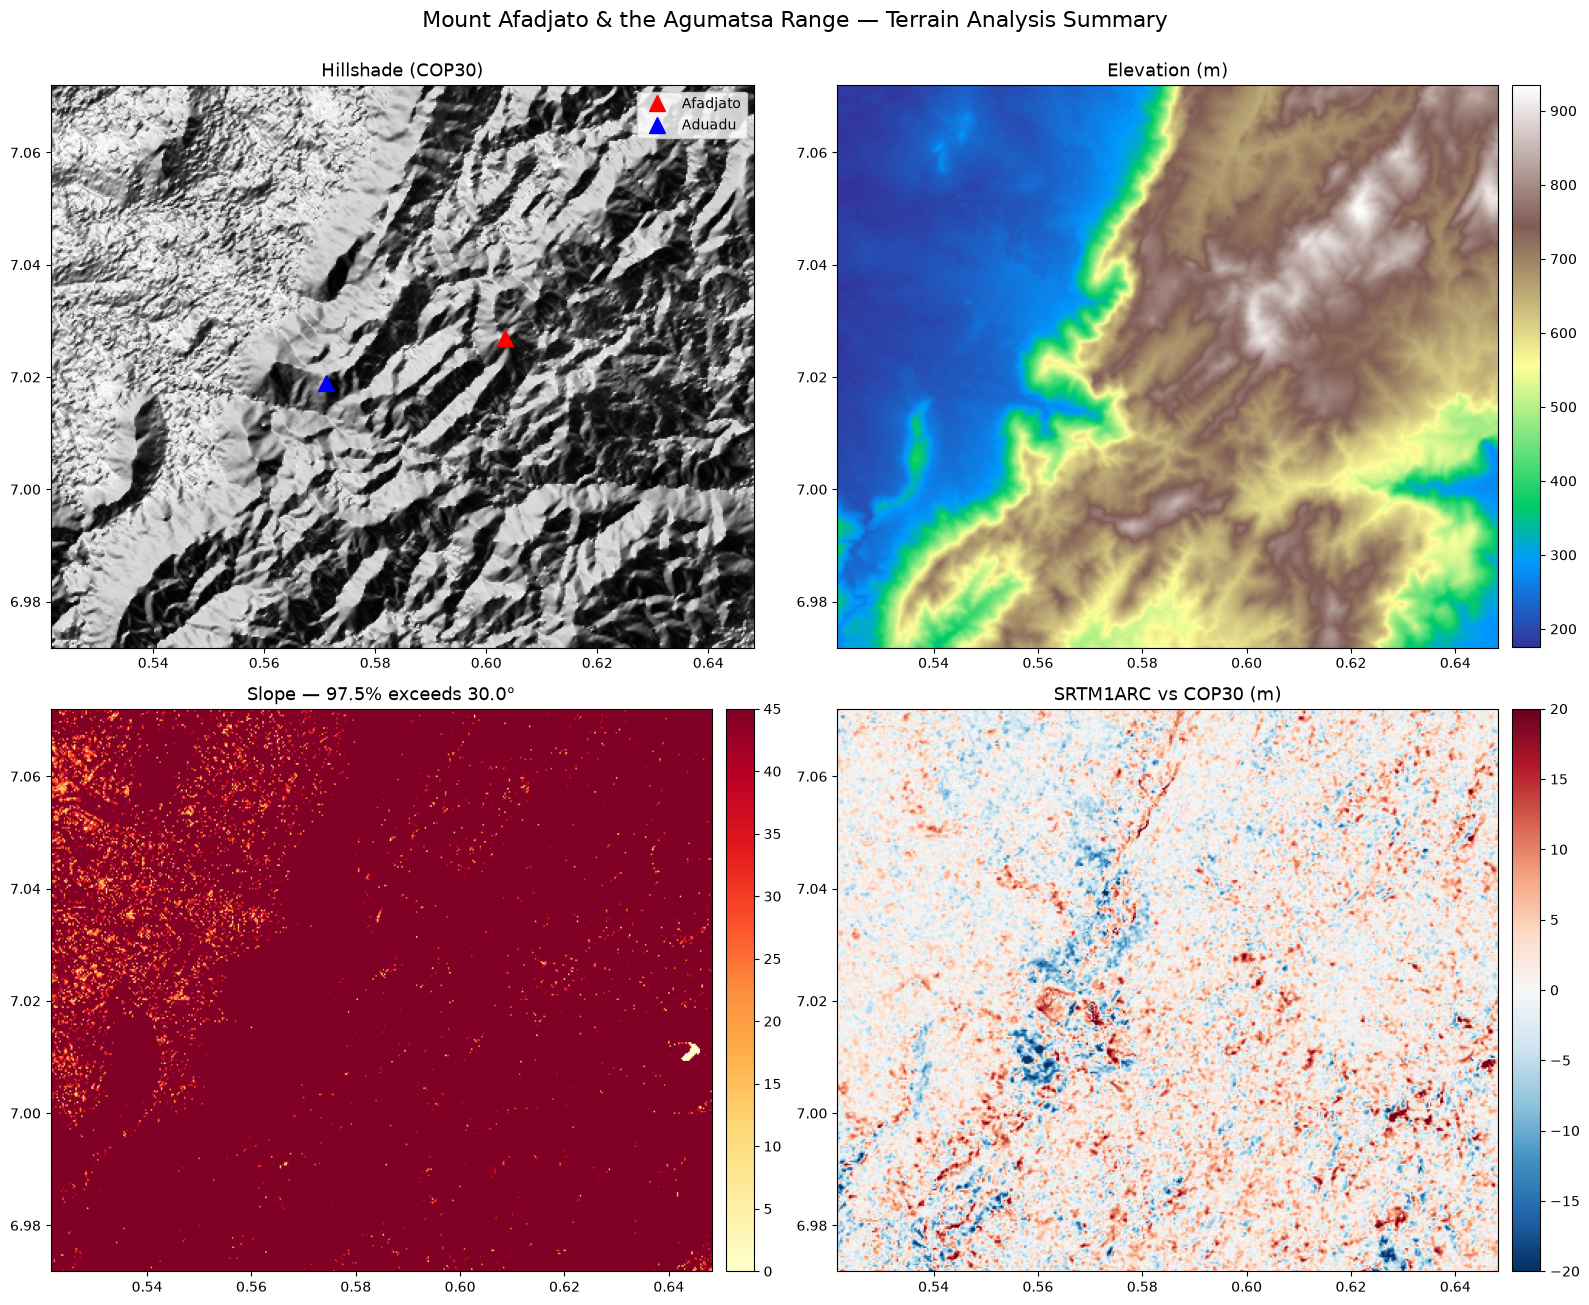

In [16]:
from pygeofetch.viz import Plotter

pl = Plotter(figsize=(20, 17), dpi=150)

pl.plot_terrain_summary(
    dem=reference_path,                     # Your DEM path (e.g., "data/dem.tif")
    # hillshade=hillshade_path,               # Your hillshade path (or None to auto-generate)
    # slope=slope_path,                       # Your slope path (or None to auto-generate)
    diffs=diffs,                            # Dict of difference maps (e.g., {"copernicus": "copernicus_minus_aster.tif"})
    summit_points={
        "Afadjato": afadjato_summit,        # Tuple: (longitude, latitude)
        "Aduadu": aduadu_summit,            # Tuple: (longitude, latitude)
    },
    primary_source=primary_source,          # e.g., "ASTER", "Copernicus", "SRTM"
    steep_threshold=30.0,
    vmin_diff=-20.0,
    vmax_diff=20.0,
    title="Mount Afadjato & the Agumatsa Range — Terrain Analysis Summary",
    # output=output_dir / "afadjato_summary.png",
    figsize=(16, 13),
    dpi=150,
    colormap_elevation="terrain",
    colormap_slope="YlOrRd",
    colormap_diff="RdBu_r",
)

print(f"✅ Terrain summary saved to: {output_dir / 'afadjato_summary.png'}")

## 8. Interactive map


In [ ]:
from pygeofetch.processing.base import _safe_write_band

mv = MapViewer(center=(afadjato_summit[1], afadjato_summit[0]), zoom=13)
hillshade_tif = output_dir / "hillshade.tif"
_safe_write_band(hillshade.astype(np.float32), dem_profile, hillshade_tif)
mv.add_raster(str(hillshade_tif), colormap="gray", layer_name="Hillshade", opacity=0.8)
mv.add_basemap("SATELLITE")
map_path = output_dir / "interactive_terrain_map.html"
mv.save(map_path)
print(f"Interactive map saved: {map_path}")


14:21:58 INFO [         map] Raster layer added: Hillshade
14:21:58 INFO [         map] Map saved → data/afadjato_dem/interactive_terrain_map.html
Interactive map saved: data/afadjato_dem/interactive_terrain_map.html


## 9. Save GIS-ready outputs


In [ ]:
results_dir = output_dir / "results"
results_dir.mkdir(parents=True, exist_ok=True)
_safe_write_band(slope.astype(np.float32), dem_profile, results_dir / "slope_degrees.tif")
_safe_write_band(aspect.astype(np.float32), dem_profile, results_dir / "aspect_degrees.tif")
_safe_write_band(hillshade.astype(np.float32), dem_profile, results_dir / "hillshade.tif")
for product, arr in diffs.items():
    _safe_write_band(arr.astype(np.float32), dem_profile, results_dir / f"diff_{product}_vs_{primary_source}.tif")
print(f"Saved to: {results_dir}")
for f in sorted(results_dir.glob("*.tif")):
    print(f"  {f.name}")


Saved to: data/afadjato_dem/results
  aspect_degrees.tif
  diff_alos_vs_cop30.tif
  diff_nasadem_vs_cop30.tif
  diff_srtm1arc_vs_cop30.tif
  hillshade.tif
  slope_degrees.tif


## Summary

- **Real summit elevations measured directly** from live DEM data,
  cross-checking both the commonly-cited 885m figure and Wikipedia's
  noted "actual" 587m figure against a third, independent source
- **Multi-source comparison**, not a single dataset taken on faith —
  genuinely useful over rugged, forested terrain where independent
  elevation models disagree
- **Honest about the DSM/DTM distinction** — these are surface models
  with real canopy influence over this forested range, not bare-earth
  DTMs; a genuine Canopy Height Model would need LiDAR this session
  didn't have access to
- **`opentopography` used for the first time this project** — not
  previously in the hardened, independently-verified provider tier;
  treat this run as its first real test, and check the results
  carefully rather than assume they're correct because the pipeline
  didn't crash

### References

- Wikipedia. Mount Afadja / Mount Aduadu (summit coordinates and elevation figures).
- BirdLife International. Mount Afadjato-Agumatsa Range Forest IBA factsheet (area, biodiversity).
- OpenTopography (SRTM, Copernicus DEM, NASADEM, ALOS World 3D).
